# Feature Engineering

## 1. Goal:
- Transform cleaned data into a feature set suitable for ML models
- Select and justify relevant features for prediction
- Encode categorical variables (e.g., one-hot, label encoding)
- Create additional useful features (e.g., text length, keyword-based features)
- Convert textual data into numerical representations
- Scale/normalize numerical features if needed
- Split dataset into training and test sets
- Produce a final feature matrix ready for modeling and implement the logic in `src/`

## 2. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from tqdm.auto import tqdm

## 3. Load Dataset

Load the raw dataset and verify shape before any transformations.

In [3]:
df = pd.read_csv("../data/processed/cleaned_job_postings.csv")

In [4]:
print(f"Shape: {df.shape}")
df.head()

Shape: (123545, 24)


,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,remote_allowed,application_type,expiry,formatted_experience_level,listed_time,posting_domain,currency,normalized_salary,zip_code,fips
0,921716,corcoran sawyer smith,marketing coordinator,job descriptiona leading real estate firm in n...,20.0,HOURLY,"princeton, nj",2774458.0,20.0,NaN,...,NaN,ComplexOnsiteApply,1.715990e+12,NaN,1.713398e+12,NaN,USD,38480.0,8540.0,34021.0
1,1829192,NaN,mental health therapist/counselor,"at aspen therapy and wellness , we are committ...",50.0,HOURLY,"fort collins, co",NaN,1.0,NaN,...,NaN,ComplexOnsiteApply,1.715450e+12,NaN,1.712858e+12,NaN,USD,83200.0,80521.0,8069.0
2,10998357,the national exemplar,assitant restaurant manager,the national exemplar is accepting application...,65000.0,YEARLY,"cincinnati, oh",64896719.0,8.0,NaN,...,NaN,ComplexOnsiteApply,1.715870e+12,NaN,1.713278e+12,NaN,USD,55000.0,45202.0,39061.0
3,23221523,"abrams fensterman, llp",senior elder law / trusts and estates associat...,senior associate attorney - elder law / trusts...,175000.0,YEARLY,"new hyde park, ny",766262.0,16.0,NaN,...,NaN,ComplexOnsiteApply,1.715488e+12,NaN,1.712896e+12,NaN,USD,157500.0,11040.0,36059.0
4,35982263,NaN,service technician,looking for hvac service tech with experience ...,80000.0,YEARLY,"burlington, ia",NaN,3.0,NaN,...,NaN,ComplexOnsiteApply,1.716044e+12,NaN,1.713452e+12,NaN,USD,70000.0,52601.0,19057.0


## 4. Text Feature Engineering
Initialize the feature engineering dataframe as a copy of the cleaned data, so all transformations go into `df_fe` while `df` remains untouched.

In [5]:
df_fe = df.copy()
print(f"Feature engineering dataframe initialized: {df_fe.shape}")

Feature engineering dataframe initialized: (123545, 24)


### 4.1 Salary Extraction and Normalization

This subsection extracts numerical pay structures from the unstructured text descriptions. It handles ranges by taking their midpoint, maps unique localized pay frequencies (`hourly`, `daily`, `yearly`), ignores false-positive features like `401(k)` options, and annualizes rates dynamically to build a standardized numerical tracking feature.

In [6]:
def clean_and_parse_number(num_str):
    """Removes currency symbols and converts string numbers to floats."""
    if not num_str:
        return np.nan
    clean_str = re.sub(r'[\$,\s]', '', num_str)
    try:
        return float(clean_str)
    except ValueError:
        return np.nan

def determine_period(match_text):
    """Detects the pay period from the text block context."""
    text = match_text.lower()
    if any(p in text for p in ['hour', 'hr', 'hourly', '/hr']):
        return 'hourly'
    if any(p in text for p in ['day', 'daily', '/day']):
        return 'daily'
    if any(p in text for p in ['year', 'yr', 'annual', 'annually', 'salary', 'compensation', '/yr']):
        return 'yearly'
    return 'unknown'

def annualize_amount(amount, period):
    """Normalizes an amount to a yearly scale based on its specific period."""
    if not amount or period == 'unknown' or not period:
        return np.nan
    if period == 'hourly':
        return amount * 40 * 52  # Standard 2,080 hour work year
    if period == 'daily':
        return amount * 5 * 52   # Standard 260 day work year
    return amount                # Already yearly

def extract_salary_from_description(text):
    if not isinstance(text, str) or not text.strip():
        return 0.0

    # Base regex patterns protecting against 401k variations using negative lookahead
    money_num = r'\d{1,3}(?:,\d{3})*(?:\.\d{2})?(?!\s*k\b)'
    money_pattern = rf'\$\s*{money_num}(?:\s*(?:-|–|to)\s*\$?\s*{money_num})?'
    
    keywords = r'(?:pay(?:| range)?|salary|wage|hourly rate|compensation|starting at|from)'
    timeframes = r'(?:hour|hr|hourly|year|yr|annually|per year|annual salary|one day|day|daily)'

    patterns = [
        rf'{keywords}\s*[:\-–]?\s*(?:from\s*)?({money_pattern}(?:\s*(?:/|per\s*)?{timeframes})?)',
        rf'({money_pattern}\s*(?:/|per\s*)?{timeframes})',
        rf'({money_pattern})' 
    ]
    
    master_regex = re.compile('|'.join(patterns), re.IGNORECASE)
    annualized_candidates = []

    for match_obj in master_regex.finditer(text):
        clean_match = next((g.strip() for g in match_obj.groups() if g), "")
        if not clean_match:
            continue
            
        numbers = re.findall(r'\$?(\d{1,3}(?:,\d{3})*(?:\.\d{2})?)(?!\s*k\b)', clean_match)
        parsed_vals = [clean_and_parse_number(n) for n in numbers if clean_and_parse_number(n) is not None]
        
        if parsed_vals:
            # Gather localized text window context for this specific snippet
            start_idx = max(0, match_obj.start() - 15)
            end_idx = min(len(text), match_obj.end() + 15)
            context_window = text[start_idx:end_idx]
            
            match_period = determine_period(context_window)
            
            # Use the average/midpoint if a range is provided
            match_base_value = sum(parsed_vals) / len(parsed_vals)
            match_annualized = round(annualize_amount(match_base_value, match_period), 2)
            
            if match_annualized > 0:
                annualized_candidates.append((match_annualized, match_period))

    if annualized_candidates:
        # Prioritize matching explicitly stated yearly schedules over fallback equivalents
        yearly_options = [c for c in annualized_candidates if c[1] == 'yearly']
        best_candidate = yearly_options[0] if yearly_options else annualized_candidates[0]
        return best_candidate[0]

    return 0.0

In [7]:
df_fe["extracted_salary"] = df_fe["description"].apply(extract_salary_from_description)

In [8]:
df_fe[['normalized_salary', "extracted_salary"]].head()

,normalized_salary,extracted_salary
0,38480.0,39520.0
1,83200.0,62400.0
2,55000.0,0.0
3,157500.0,157500.0
4,70000.0,0.0


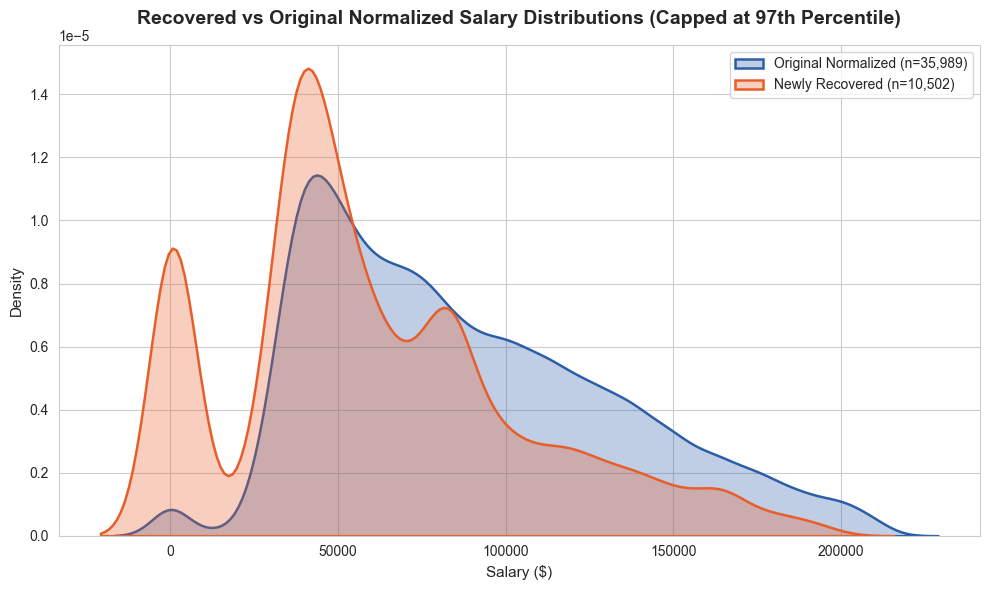

Newly Recovered Salaries: 10,502
Estimated Missing After Imputation: 77,054 (62.4%)


In [13]:
# Cap extracted salaries at the 99th percentile
valid_extracted = df_fe.loc[df_fe["extracted_salary"] > 0, "extracted_salary"]
if not valid_extracted.empty:
    percentile_97 = np.percentile(valid_extracted, 97)
    df_fe.loc[df_fe["extracted_salary"] > percentile_97, "extracted_salary"] = np.nan

# Identify newly recovered salaries
is_normalized_missing = df_fe["normalized_salary"].isna() | (df_fe["normalized_salary"] == 0)
is_extracted_present = df_fe["extracted_salary"].notna() & (df_fe["extracted_salary"] > 0)
newly_recovered_df = df_fe[is_normalized_missing & is_extracted_present].copy()

# --- Visualization ---

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

recovered_salaries = newly_recovered_df["extracted_salary"].dropna()
recovered_salaries = recovered_salaries[recovered_salaries > 0]

original_normalized = df_fe.loc[
    (df_fe["normalized_salary"].notna()) & (df_fe["normalized_salary"] > 0),
    "normalized_salary"
]

if not recovered_salaries.empty and not original_normalized.empty:
    combined_cap = np.percentile(
        np.concatenate([original_normalized.values, recovered_salaries.values]),
        97
    )
    norm_capped = original_normalized[original_normalized <= combined_cap]
    recov_capped = recovered_salaries[recovered_salaries <= combined_cap]

    sns.kdeplot(norm_capped, ax=ax, color="#2B5EA7", fill=True, alpha=0.3,
                linewidth=1.8, label=f"Original Normalized (n={len(original_normalized):,})")
    sns.kdeplot(recov_capped, ax=ax, color="#E85D2A", fill=True, alpha=0.3,
                linewidth=1.8, label=f"Newly Recovered (n={len(recovered_salaries):,})")

    ax.set_xlabel("Salary ($)", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.legend(fontsize=10)

ax.set_title("Recovered vs Original Normalized Salary Distributions (Capped at 97th Percentile)",
             fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

# --- Post-imputation missing stats ---
total_rows = len(df_fe)
newly_recovered_count = len(recovered_salaries)
missing_before = is_normalized_missing.sum()
missing_after = missing_before - newly_recovered_count
missing_pct_after = (missing_after / total_rows) * 100

print(f"Newly Recovered Salaries: {newly_recovered_count:,}")
print(f"Estimated Missing After Imputation: {missing_after:,} ({missing_pct_after:.1f}%)")

- **9,782 new salary values** recovered from unstructured text, but at least **77,774 (63.0%)** will still be missing after imputation
- Recovered salaries skew lower, clustering around **$30,000–$50,000** (likely from annualized hourly/daily rates)
- Visible spike near **$0** indicates false extractions (e.g., benefit descriptions, formatting artifacts) that need cleaning
- Plot is capped at the 97th percentile; upper-end outliers still exist in raw data and will be handled in later steps

### 4.2 Domain Extraction

Load pre-computed domain similarity scores from the external classification
script (`domain_probabilities.csv`). Each row contains cosine-similarity
scores between a job description and 13 industry-domain prototypes, produced
by a domain-aware BERT model
([`0xnbk/nbk-ats-domain-v1-en`](https://huggingface.co/0xnbk/nbk-ats-domain-v1-en)).

The highest-scoring domain is assigned as the label. If the best similarity
falls below `SIMILARITY_THRESHOLD` the posting receives the label `Unknown`.
The 14 resulting labels are one-hot encoded and the best similarity score is
kept as a continuous feature.

In [14]:
SIMILARITY_THRESHOLD = 0.35

# ---- Load pre-computed domain similarities ----
df_domains = pd.read_csv("../data/processed/domain_probabilities.csv")

# Similarity columns (everything except job_id)
sim_cols = [c for c in df_domains.columns if c.startswith("domain_sim_")]
domain_names = [c.replace("domain_sim_", "") for c in sim_cols]

# ---- Derive domain label + best score ----
sim_values = df_domains[sim_cols].values
best_idx = sim_values.argmax(axis=1)
best_score = sim_values[np.arange(len(sim_values)), best_idx]

df_domains["domain"] = np.where(
    best_score >= SIMILARITY_THRESHOLD,
    np.array(domain_names)[best_idx],
    "Unknown",
)
df_domains["domain_similarity"] = best_score

# ---- Merge into feature dataframe ----
df_fe = df_fe.merge(df_domains[["job_id", "domain", "domain_similarity"]], on="job_id", how="left")

# ---- One-hot encode domain labels ----
domain_dummies = pd.get_dummies(df_fe["domain"], prefix="domain")
df_fe = pd.concat([df_fe, domain_dummies], axis=1)

print(f"Domain columns added to df_fe  |  shape: {df_fe.shape}")
print(f"Unique domains assigned: {df_fe['domain'].nunique()}")

Domain columns added to df_fe  |  shape: (123545, 41)
Unique domains assigned: 14


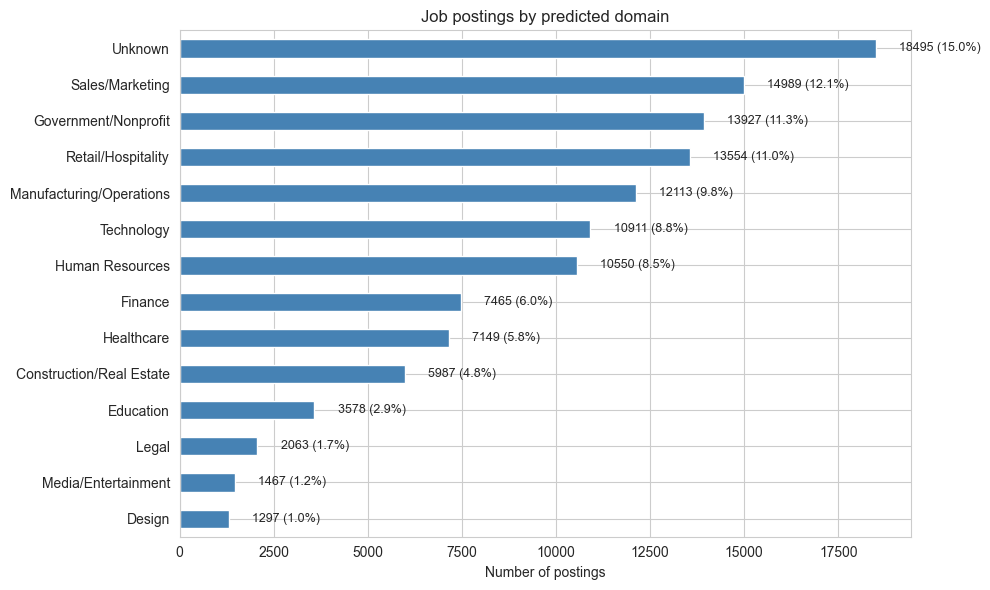

In [15]:
domain_cols = [
    "domain_Construction/Real Estate", "domain_Design", "domain_Education", 
    "domain_Finance", "domain_Government/Nonprofit", "domain_Healthcare", 
    "domain_Human Resources", "domain_Legal", "domain_Manufacturing/Operations", 
    "domain_Media/Entertainment", "domain_Retail/Hospitality", "domain_Sales/Marketing", 
    "domain_Technology", "domain_Unknown"
]

domain_counts = df_fe[domain_cols].sum()
domain_counts.index = domain_counts.index.str.replace("domain_", "")
domain_counts = domain_counts.sort_values()

total_count = domain_counts.sum()
percentages = (domain_counts / total_count * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 6))
bars = domain_counts.plot.barh(ax=ax, color="steelblue", edgecolor="white")

for i, (domain, count) in enumerate(domain_counts.items()):
    pct = percentages[domain]
    ax.text(count + (total_count * 0.005), i, f'{int(count)} ({pct}%)', 
            va='center', fontsize=9)

ax.set_xlabel("Number of postings")
ax.set_title("Job postings by predicted domain")
plt.tight_layout()
plt.show()

**Observations:**

- The similarity threshold of **0.35** produces 14 domain classes (13 named + `Unknown`).
- `Unknown` has the highest count (~15%), likely capturing jobs that
  span multiple domains or do not fit neatly into any single one of the 13 defined categories.
- Top named domains are **Sales/Marketing**, **Government/Nonprofit**, and
  **Retail/Hospitality**, each exceeding 13,000 postings.
- Smaller domains like **Design**, **Media/Entertainment**, and **Legal** each
  hold fewer than 2,500 postings, reflecting their niche presence in the dataset.
- For the feature matrix the 14 domain labels will be **one-hot encoded**,
  and `domain_similarity` (confidence score) will be included as an additional
  continuous feature for downstream modelling.

### 4.3 Title-Based Experience Level Extraction

This subsection extracts seniority signals from job titles using targeted regex patterns to fill gaps in `experience_level_ord`. It scans titles top-down (Executive to Intern) so compound titles like *"Senior Director"* resolve to the highest applicable level. False-positive guards filter out misleading compounds where a seniority keyword loses its meaning (e.g., *"Executive Assistant"* is not executive-level, *"Senior Living Facility"* is not mid-senior).

In [16]:
TITLE_EXPERIENCE_PATTERNS = [
    # 0 - Internship
    (0, re.compile(r'\b(?:intern|internship)\b', re.IGNORECASE)),

    # 1 - Entry level
    (1, re.compile(r'\b(?:junior|jr\.?|entry[\s-]?level|trainee|apprentice)\b', re.IGNORECASE)),

    # 2 - Associate
    (2, re.compile(r'\b(?:associate)\b', re.IGNORECASE)),

    # 3 - Mid-Senior level
    (3, re.compile(r'\b(?:senior|sr\.?|staff|principal)\b', re.IGNORECASE)),

    # 4 - Director
    (4, re.compile(r'\b(?:director)\b', re.IGNORECASE)),

    # 5 - Executive
    (5, re.compile(
        r'\b(?:vice[\s-]?president|vp|c[eoftim]o|chief\s\w+\sofficer|president|partner)\b',
        re.IGNORECASE
    )),
]

# Titles where the seniority keyword loses its meaning
FALSE_POSITIVE_GUARDS = {
    5: re.compile(r'\b(?:executive\s+(?:assistant|secretary|coordinator|admin))\b', re.IGNORECASE),
    3: re.compile(r'\b(?:senior\s+(?:living|care|center|community|services))\b', re.IGNORECASE),
    2: re.compile(
        r'\b(?:'
        r'(?:sales|retail|warehouse|fulfillment|store|stock|team|pickup|delivery|deli)\s+associate'
        r'|associate\s+(?:dentist|veterinarian|pastor|broker)'
        r')\b',
        re.IGNORECASE
    ),
}


def extract_experience_from_title(title):
    """
    Returns an ordinal experience level (0-5) if an obvious keyword is found,
    otherwise returns None. Scans from highest seniority downward so that
    'Senior Director' maps to Director (4) rather than Mid-Senior (3),
    and 'Associate Director' maps to Director (4) rather than Associate (2).
    """
    if not isinstance(title, str) or not title.strip():
        return None

    # scan top-down (executive -> director -> senior -> associate -> entry -> intern)
    for level, pattern in reversed(TITLE_EXPERIENCE_PATTERNS):
        if pattern.search(title):
            guard = FALSE_POSITIVE_GUARDS.get(level)
            if guard and guard.search(title):
                continue
            return level

    return None

In [18]:
# ── Apply extraction to all rows ──

df_fe['title_experience_extracted'] = df_fe['title'].apply(extract_experience_from_title)

total = len(df_fe)
extracted_count = df_fe['title_experience_extracted'].notna().sum()

level_names = {0: 'Internship', 1: 'Entry', 2: 'Associate',
               3: 'Mid-Senior', 4: 'Director', 5: 'Executive'}

print(f"Total rows:              {total:,}")
print(f"Regex extracted value:   {extracted_count:,} ({extracted_count/total*100:.1f}%)")
print(f"No match (None):         {total - extracted_count:,} ({(total - extracted_count)/total*100:.1f}%)")
print("\nExtracted level distribution:")
for code, name in level_names.items():
    count = (df_fe['title_experience_extracted'] == code).sum()
    print(f"  {code} - {name}: {count:,}")

Total rows:              123,545
Regex extracted value:   24,132 (19.5%)
No match (None):         99,413 (80.5%)

Extracted level distribution:
  0 - Internship: 1,478
  1 - Entry: 1,720
  2 - Associate: 3,629
  3 - Mid-Senior: 11,456
  4 - Director: 4,147
  5 - Executive: 1,702


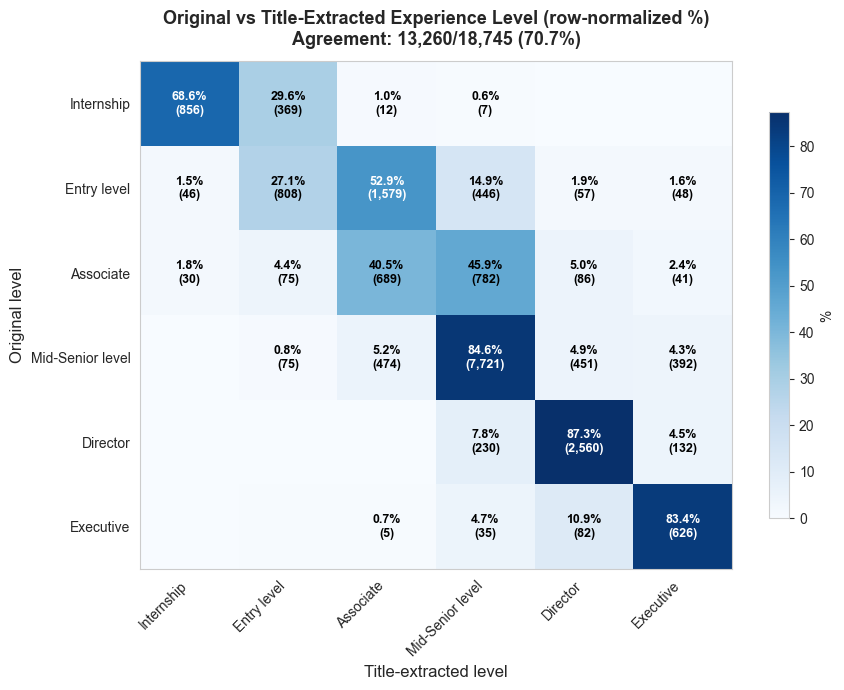

In [20]:
# ── Confusion heatmap: original (rows) vs extracted (cols) ──

level_names = {0: 'Internship', 1: 'Entry level', 2: 'Associate',
               3: 'Mid-Senior level', 4: 'Director', 5: 'Executive'}

# Map extracted codes to the same labels as formatted_experience_level
df_fe['title_experience_label'] = df_fe['title_experience_extracted'].map(level_names)

both_exist = df_fe['formatted_experience_level'].notna() & df_fe['title_experience_label'].notna()
df_both = df_fe.loc[both_exist, ['title', 'formatted_experience_level', 'title_experience_label']].copy()
df_both['match'] = df_both['formatted_experience_level'] == df_both['title_experience_label']

n_both = len(df_both)
n_match = df_both['match'].sum()

# Order labels by seniority for readable axes
label_order = ['Internship', 'Entry level', 'Associate',
               'Mid-Senior level', 'Director', 'Executive']

ct = pd.crosstab(
    df_both['formatted_experience_level'],
    df_both['title_experience_label'],
)
ct = ct.reindex(index=label_order, columns=label_order, fill_value=0)
ct_norm = ct.div(ct.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(ct_norm.values, cmap='Blues', aspect='auto')

ax.grid(False)
ax.set_xticks(range(len(ct_norm.columns)))
ax.set_yticks(range(len(ct_norm.index)))
ax.set_xticklabels(ct_norm.columns, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(ct_norm.index, fontsize=10)
ax.set_xlabel('Title-extracted level', fontsize=12)
ax.set_ylabel('Original level', fontsize=12)

for i in range(len(ct_norm.index)):
    for j in range(len(ct_norm.columns)):
        val = ct_norm.values[i, j]
        count = ct.values[i, j]
        if val > 0.5:
            color = 'white' if val > 50 else 'black'
            ax.text(j, i, f'{val:.1f}%\n({count:,})', ha='center', va='center',
                    fontsize=9, fontweight='bold', color=color)

fig.colorbar(im, ax=ax, label='%', shrink=0.8)
ax.set_title(
    f'Original vs Title-Extracted Experience Level (row-normalized %)\n'
    f'Agreement: {n_match:,}/{n_both:,} ({n_match/n_both*100:.1f}%)',
    fontsize=13, fontweight='bold', pad=12
)
plt.tight_layout()
plt.show()

**Interpretation:** Overall agreement between original and regex-extracted levels is **70.7%**, with most disagreements occurring between adjacent levels (e.g., Entry↔Associate, Associate↔Mid-Senior). Senior levels show strong agreement (Mid-Senior 84.6%, Director 87.3%, Executive 83.4%). The regex extracted **5,387 new fills (4.4%)** for previously missing values. Given that errors are predominantly one-step mismatches and the fill volume is small, these new values are retained to reduce missingness in `experience_level_ord`.

In [21]:
# ── Fill missing formatted_experience_level with regex-extracted values ──

new_fills = df_fe['formatted_experience_level'].isna() & df_fe['title_experience_label'].notna()
fill_count = new_fills.sum()

df_fe['formatted_experience_level'] = df_fe['formatted_experience_level'].fillna(
    df_fe['title_experience_label']
)

# Clean up helper columns
df_fe.drop(columns=['title_experience_extracted', 'title_experience_label'], inplace=True)

remaining_nan = df_fe['formatted_experience_level'].isna().sum()
total = len(df_fe)
print(f"Filled {fill_count:,} missing values from title extraction")
print(f"Remaining NaN: {remaining_nan:,} ({remaining_nan/total*100:.1f}%)")

Filled 5,387 missing values from title extraction
Remaining NaN: 23,958 (19.4%)


### 4.4 Title and Description Length

Simple length-based features that capture posting verbosity. Longer descriptions often indicate more detailed or senior roles, while title word count reflects naming complexity.

In [22]:
# ── Title & description length features ──
df_fe['title_length']    = df_fe['title'].str.len()
df_fe['desc_word_count'] = df_fe['description'].fillna('').str.split().str.len()

df_fe[['title_length', 'desc_word_count']].describe().round(1)

,title_length,desc_word_count
count,123545.0,123545.0
mean,31.5,523.2
std,16.2,302.1
min,2.0,0.0
25%,20.0,298.0
50%,28.0,478.0
75%,39.0,696.0
max,200.0,3400.0


## 5. Numerical Features Engineering

## 6. Categorical Encoding (low cardinality)

Encoding strategy for low-cardinality categorical columns:

- `pay_period` - One-hot encoding (will be used in normalized salary calculation; missing values stay as all-zeros)
- `formatted_work_type` - One-hot encoding
- `application_type` - One-hot encoding
- `formatted_experience_level` - Ordinal encoding (natural hierarchy: Internship < Entry level < Associate < Mid-Senior level < Director < Executive)
- `currency` - Skipped here; used only in normalized salary calculation and removed in later steps

### 6.1 One-Hot Encoding


In [ ]:
ohe_columns = ['pay_period', 'formatted_work_type', 'application_type']

for col in ohe_columns:
    dummies = pd.get_dummies(df_fe[col], prefix=col, dtype=int)
    df_fe = pd.concat([df_fe, dummies], axis=1)
    df_fe.drop(columns=[col], inplace=True)

print(f"Columns after one-hot encoding: {df_fe.shape[1]}")
print("New OHE columns:")
for col in ohe_columns:
    ohe_cols = [c for c in df_fe.columns if c.startswith(col + '_')]
    print(f"  {col}: {ohe_cols}")

KeyError: 'pay_period'

### 6.2 Ordinal Encoding: formatted_experience_level

In [ ]:

experience_order = {
    'Internship':        0,
    'Entry level':       1,
    'Associate':         2,
    'Mid-Senior level':  3,
    'Director':          4,
    'Executive':         5
}

df_fe['experience_level_ord'] = df['formatted_experience_level'].map(experience_order)

print("Ordinal mapping applied:")
for level, code in experience_order.items():
    count = (df_fe['experience_level_ord'] == code).sum()
    print(f"  {code} = {level} ({count:,} rows)")

missing = df_fe['experience_level_ord'].isna().sum()
print(f"  NaN = missing ({missing:,} rows)")

df.drop(columns=['formatted_experience_level'], inplace=True)

Ordinal mapping applied:
  0 = Internship (1,441 rows)
  1 = Entry level (36,561 rows)
  2 = Associate (9,817 rows)
  3 = Mid-Senior level (41,413 rows)
  4 = Director (3,746 rows)
  5 = Executive (1,222 rows)
  NaN = missing (29,345 rows)


### Encoding summary

| Column | Method | Notes |
|--------|--------|-------|
| `pay_period` | One-hot | NaN rows get all-zero dummy columns; used in salary normalization |
| `formatted_work_type` | One-hot | No missing values |
| `application_type` | One-hot | No missing values |
| `formatted_experience_level` | Ordinal (0-5) | Natural rank order; NaN preserved for later imputation |
| `currency` | No encoding | Temporary helper for salary normalization; dropped later |